In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
file_path = "/content/drive/MyDrive/Lloyds_Job_Simulation_Tasks/Customer_Churn_Data_Large.xlsx"

xls = pd.ExcelFile(file_path)
xls.sheet_names

['Customer_Demographics',
 'Transaction_History',
 'Customer_Service',
 'Online_Activity',
 'Churn_Status']

In [4]:
transactions = pd.read_excel(xls, "Transaction_History")
service = pd.read_excel(xls, "Customer_Service")
online = pd.read_excel(xls, "Online_Activity")
churn = pd.read_excel(xls, "Churn_Status")

# **EDA**

Churn Distribution

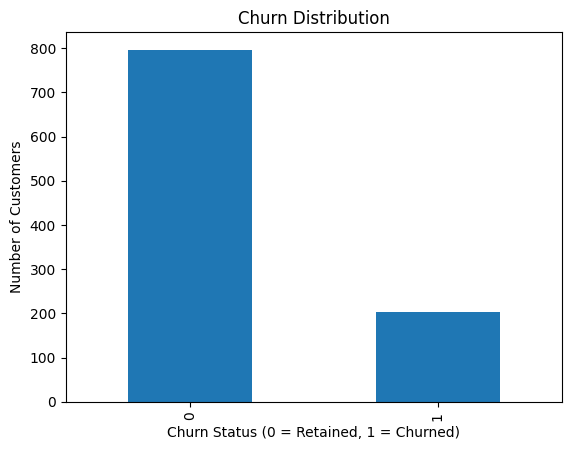

In [5]:
churn['ChurnStatus'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn Status (0 = Retained, 1 = Churned)")
plt.ylabel("Number of Customers")
plt.show()

Transaction Behaviour

Histogram: Amount Spent

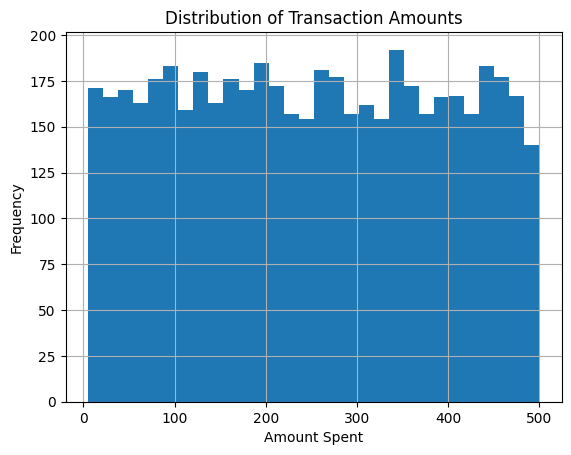

In [6]:
transactions['AmountSpent'].hist(bins=30)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount Spent")
plt.ylabel("Frequency")
plt.show()

Boxplot (to detect outliers)

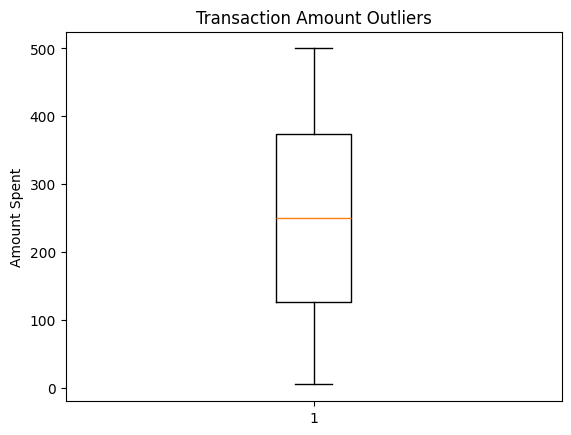

In [7]:
plt.boxplot(transactions['AmountSpent'])
plt.title("Transaction Amount Outliers")
plt.ylabel("Amount Spent")
plt.show()

# Customer service behaviour

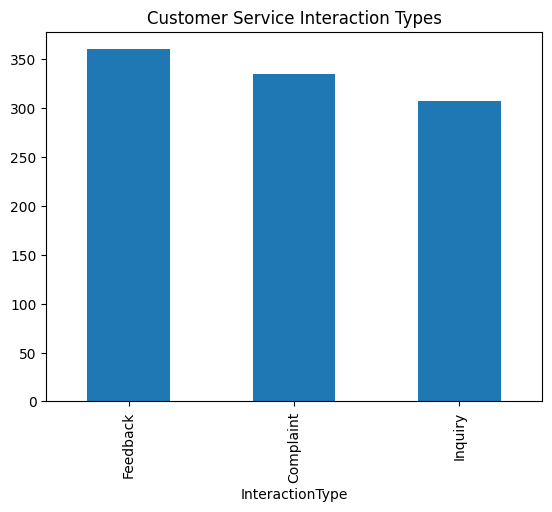

In [8]:
service['InteractionType'].value_counts().plot(kind='bar')
plt.title("Customer Service Interaction Types")
plt.show()

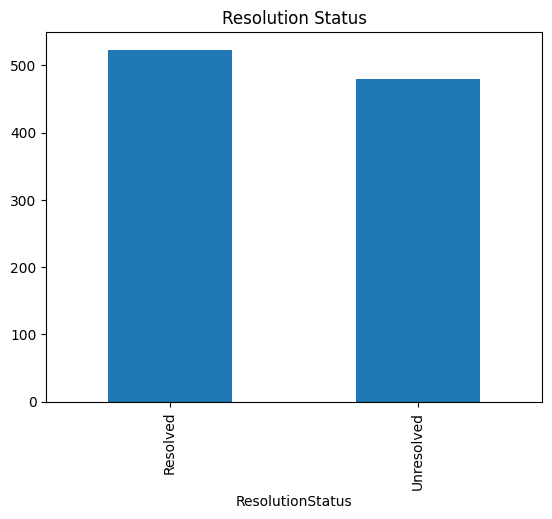

In [9]:
service['ResolutionStatus'].value_counts().plot(kind='bar')
plt.title("Resolution Status")
plt.show()

# Online activity

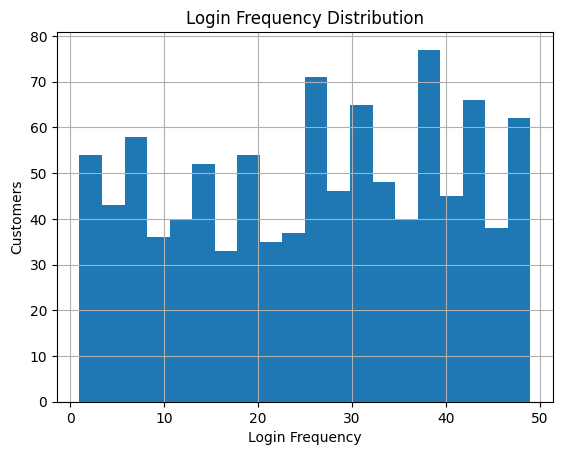

In [10]:
online['LoginFrequency'].hist(bins=20)
plt.title("Login Frequency Distribution")
plt.xlabel("Login Frequency")
plt.ylabel("Customers")
plt.show()

# **Data Cleaning & Preprocessing**

# Feature Engineering

Transactions → customer features

In [11]:
txn_features = transactions.groupby('CustomerID').agg(
    TotalAmountSpent=('AmountSpent', 'sum'),
    NumberOfTransactions=('AmountSpent', 'count')
).reset_index()

Customer service → customer features

In [12]:
service_features = service.groupby('CustomerID').agg(
    NumberOfServiceInteractions=('InteractionType', 'count'),
    UnresolvedInteractions=('ResolutionStatus', lambda x: (x == 'Unresolved').sum())
).reset_index()

Online activity → customer features

In [13]:
online['LastLoginDate'] = pd.to_datetime(online['LastLoginDate'])

online['DaysSinceLastLogin'] = (
    online['LastLoginDate'].max() - online['LastLoginDate']
).dt.days

online_features = online.groupby('CustomerID').agg(
    LoginFrequency=('LoginFrequency', 'mean'),
    DaysSinceLastLogin=('DaysSinceLastLogin', 'mean'),
    ServiceUsage=('ServiceUsage', 'first')
).reset_index()

# Merge everything together

In [14]:
data = churn.merge(txn_features, on='CustomerID', how='left') \
            .merge(service_features, on='CustomerID', how='left') \
            .merge(online_features, on='CustomerID', how='left')

# Handle missing values

In [15]:
# Numerical columns
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

# Categorical columns
cat_cols = data.select_dtypes(include=['object']).columns
data[cat_cols] = data[cat_cols].fillna(data[cat_cols].mode().iloc[0])

# Handle Outliers

In [16]:
def cap_outliers(series):
    lower = series.quantile(0.01)
    upper = series.quantile(0.99)
    return series.clip(lower, upper)

data['TotalAmountSpent'] = cap_outliers(data['TotalAmountSpent'])
data['LoginFrequency'] = cap_outliers(data['LoginFrequency'])

# Encode categorical variables

In [17]:
data = pd.get_dummies(data, columns=['ServiceUsage'], drop_first=True)

# Standardise numerical features

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_cols = [
    'TotalAmountSpent',
    'NumberOfTransactions',
    'NumberOfServiceInteractions',
    'UnresolvedInteractions',
    'LoginFrequency',
    'DaysSinceLastLogin'
]

data[scaled_cols] = scaler.fit_transform(data[scaled_cols])

# Final Dataset

In [19]:
data.head()

,CustomerID,ChurnStatus,TotalAmountSpent,NumberOfTransactions,NumberOfServiceInteractions,UnresolvedInteractions,LoginFrequency,DaysSinceLastLogin,ServiceUsage_Online Banking,ServiceUsage_Website
0,1,0,-1.159172,-1.557954,-1.223522,-1.507865,0.575702,-1.021557,False,False
1,2,1,0.386676,0.747849,-1.223522,-1.507865,-1.488513,-1.450763,False,True
2,3,0,0.599310,0.363548,-1.223522,-1.507865,-1.630872,-1.260005,False,True
3,4,0,-0.474645,-0.020752,1.223522,0.351401,-1.702052,-0.477897,False,True
4,5,0,1.007342,1.132149,0.000000,0.351401,1.073961,-1.078785,False,True


In [20]:
data.shape

(1000, 10)

# Save Cleaned Dataset

In [21]:
data.to_csv("cleaned_customer_churn_data.csv", index=False)

# Customer Churn Prediction Model
# Lloyds Banking Group – Task 2

In [24]:
!pip install seaborn openpyxl

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from functools import reduce
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

# Load and Merge Data

In [28]:
dataframes = [pd.read_excel(xls, sheet) for sheet in xls.sheet_names]

df = reduce(lambda left, right: pd.merge(left, right, on="CustomerID"), dataframes)

print("Dataset shape after merge:", df.shape)

Dataset shape after merge: (5204, 17)


# Preprocessing

In [30]:
df = df.rename(columns={"Churn_Status": "Churn"})

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5204 entries, 0 to 5203
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        5204 non-null   int64         
 1   Age               5204 non-null   int64         
 2   Gender            5204 non-null   int64         
 3   MaritalStatus     5204 non-null   int64         
 4   IncomeLevel       5204 non-null   int64         
 5   TransactionID     5204 non-null   int64         
 6   TransactionDate   5204 non-null   datetime64[ns]
 7   AmountSpent       5204 non-null   float64       
 8   ProductCategory   5204 non-null   int64         
 9   InteractionID     5204 non-null   int64         
 10  InteractionDate   5204 non-null   datetime64[ns]
 11  InteractionType   5204 non-null   int64         
 12  ResolutionStatus  5204 non-null   int64         
 13  LastLoginDate     5204 non-null   datetime64[ns]
 14  LoginFrequency    5204 n

In [37]:
from datetime import datetime

# Reference date (today)
reference_date = pd.Timestamp("today")

# Convert datetime columns into numeric features
for col in df.select_dtypes(include=["datetime64[ns]"]).columns:
    df[col] = (reference_date - df[col]).dt.days


In [38]:
df = df.dropna()

label_encoder = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = label_encoder.fit_transform(df[col])

X = df.drop(["CustomerID", "ChurnStatus"], axis=1)
y = df["ChurnStatus"]

# Train-test split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [41]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

# Model + Hyperparameter tuning

In [42]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}


In [43]:
assert not X.select_dtypes(include=["datetime64[ns]"]).any().any(), "Datetime columns still present!"

# Model Evaluation


In [44]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.3f}")


Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       827
           1       1.00      0.95      0.98       214

    accuracy                           0.99      1041
   macro avg       0.99      0.98      0.99      1041
weighted avg       0.99      0.99      0.99      1041

ROC-AUC Score: 0.999


# Confusion Matrix

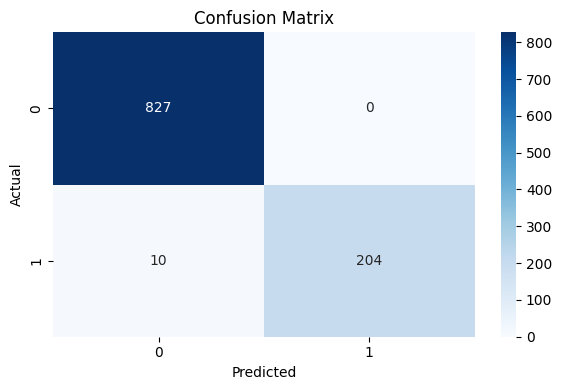

In [45]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve

<Figure size 600x400 with 0 Axes>

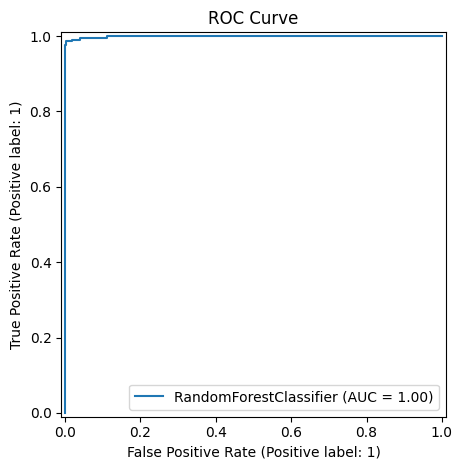

In [46]:
plt.figure(figsize=(6, 4))
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve")
plt.tight_layout()
plt.show()

# Feature Importance

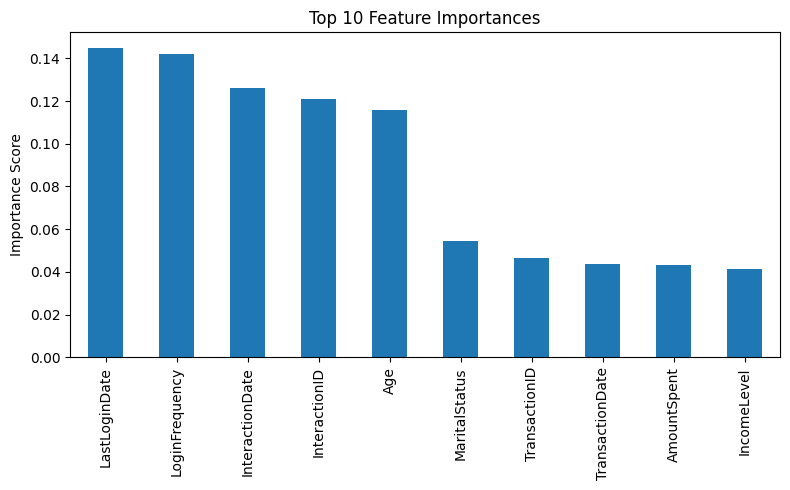

In [47]:
importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()